In [1]:
!pip install brian2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.1 MB/s eta 0:00:00


In [23]:
!cd mnist && gunzip *.gz

In [24]:
from brian2 import *
from collections import defaultdict
from pathlib import Path
from progressbar import progressbar
from random import randrange, seed as rseed
from struct import unpack
import numpy as np

# Switch between "train", "observe", and "test" to tune parameters,
# observe excitatory spiking, and test accuracy, respectively.
# Use "plot" to plot the confusion matrix.
MODE = 'train'

# Number of training, observation, and testing samples
N_TRAIN = 25_000
N_OBSERVE = 2_000
N_TEST = 1_000

# Random seed value
SEED = 42

# Storage paths
MNIST_PATH = Path('/content/mnist')
DATA_PATH = Path('data')

# Number of weight save points
N_SAVE_POINTS = 100

# Don't change these values unless you know what you're doing.
N_INP = 784
N_NEURONS = 400
V_EXC_REST = -65 * mV
V_INH_REST = -60 * mV
INTENSITY = 2

# Weights of exc->inh and inh->exc synapses
W_EXC_INH = 10.4
W_INH_EXC = 17.0

def save_npy(arr, path):
    arr = np.array(arr)
    print('%-9s %-15s => %-30s' % ('Saving', arr.shape, path))
    np.save(path, arr)

def load_npy(path):
    arr = np.load(path)
    print('%-9s %-30s => %-15s' % ('Loading', path, arr.shape))
    return arr

def read_mnist(training):
    tag = 'train' if training else 't10k'
    images = open(MNIST_PATH / ('%s-images-idx3-ubyte' % tag), 'rb')
    images.read(4)
    n_images = unpack('>I', images.read(4))[0]
    n_rows = unpack(">I", images.read(4))[0]
    n_cols = unpack(">I", images.read(4))[0]

    labels = open(MNIST_PATH / ('%s-labels-idx1-ubyte' % tag), 'rb')
    labels.read(4)
    x = np.frombuffer(images.read(), dtype = np.uint8)
    x = x.reshape(n_images, -1) / 8.0
    y = np.frombuffer(labels.read(), dtype = np.uint8)
    return x, y

def build_network(training):
    eqs = '''
    dv/dt = (v_rest - v + i_exc + i_inh) / tau_mem  : volt (unless refractory)
    i_exc = ge * -v                         : volt
    i_inh = gi * (v_inh_base - v)           : volt
    dge/dt = -ge/(1 * ms)                   : 1
    dgi/dt = -gi/(2 * ms)                   : 1
    dtimer/dt = 1                           : second
    '''
    reset = 'v = %r; timer = 0 * ms' % V_EXC_REST
    if training:
        exc_eqs = eqs + '''
        dtheta/dt = -theta / (1e7 * ms)         : volt
        '''
        arr_theta = np.ones(N_NEURONS) * 20 * mV
        reset += '; theta += 0.05 * mV'
    else:
        exc_eqs = eqs + '''
        theta                                   : volt
        '''
        arr_theta = load_npy(DATA_PATH / 'theta_A.npy') * volt
    exc_eqs = Equations(exc_eqs,
                        tau_mem = 100 * ms,
                        v_rest = V_EXC_REST,
                        v_inh_base = -100 * mV)
    # Note that this neuron has a bit of un unusual refractoriness mechanism:
    # The membrane potential is clamped for 5ms, but spikes are prevented for 50ms
    # This has been taken from the original code.
    ng_exc = NeuronGroup(
        N_NEURONS, exc_eqs,
        threshold = 'v > (theta - 72 * mV) and (timer > 50 * ms)',
        refractory = 5 * ms,
        reset = reset,
        method = 'euler',
        name = 'exc')
    ng_exc.v = V_EXC_REST
    ng_exc.theta = arr_theta

    inh_eqs = Equations(eqs,
                        tau_mem = 10 * ms,
                        v_rest = V_INH_REST,
                        v_inh_base = -85 * mV)
    ng_inh = NeuronGroup(N_NEURONS, inh_eqs,
                         threshold = 'v > -40 * mV',
                         refractory = 2 * ms,
                         reset = 'v = -45 * mV',
                         method = 'euler',
                         name = 'inh')
    ng_inh.v = V_INH_REST

    syns_exc_inh = Synapses(ng_exc, ng_inh,
                            on_pre = 'ge_post += %f' % W_EXC_INH)
    syns_exc_inh.connect(j = 'i')

    syns_inh_exc = Synapses(ng_inh, ng_exc,
                            on_pre = 'gi_post += %f' % W_INH_EXC)
    syns_inh_exc.connect("i != j")

    pg_inp = PoissonGroup(N_INP, 0 * Hz, name = 'inp')

    # During training, inp->exc synapse weights are plastic.
    model = 'w : 1'
    on_post = ''
    on_pre = 'ge_post += w'
    if training:
        on_pre += '; pre = 1.; w = clip(w - 0.0001 * post1, 0, 1.0)'
        on_post += 'post2bef = post2; w = clip(w + 0.01 * pre * post2bef, 0, 1.0); post1 = 1.; post2 = 1.'
        model += '''
        post2bef                        : 1
        dpre/dt   = -pre/(20 * ms)      : 1 (event-driven)
        dpost1/dt = -post1/(20 * ms)    : 1 (event-driven)
        dpost2/dt = -post2/(40 * ms)    : 1 (event-driven)
        '''
        weights = (np.random.random(N_INP * N_NEURONS) + 0.01) * 0.3
    else:
        weights = load_npy(DATA_PATH / 'XeAe.npy')
        if weights.shape[1] == 3:  # Convert sparse format to dense if necessary
            weights = convert_sparse_to_dense(weights, N_INP, N_NEURONS)

    syns_inp_exc = Synapses(
        pg_inp, ng_exc,
        model=model,
        on_pre=on_pre,
        on_post=on_post,
        name='inp_exc'
    )
    syns_inp_exc.connect(True)
    syns_inp_exc.delay = 'rand() * 10 * ms'
    syns_inp_exc.w = weights
    syns_inp_exc = Synapses(
        pg_inp, ng_exc,
        model = model,
        on_pre = on_pre,
        on_post = on_post,
        name = 'inp_exc'
    )
    syns_inp_exc.connect(True)
    syns_inp_exc.delay = 'rand() * 10 * ms'
    syns_inp_exc.w = weights

    exc_mon = SpikeMonitor(ng_exc, name = 'sp_exc')
    net = Network([pg_inp, ng_exc, ng_inh,
                   syns_inp_exc, syns_exc_inh, syns_inh_exc,
                   exc_mon])
    # Initialize
    net.run(0 * ms)
    return net

def show_sample(net, sample, intensity):
    exc_mon = net['sp_exc']
    prev = exc_mon.count[:]
    net['inp'].rates = sample * intensity * Hz
    net.run(350 * ms)
    # Don't count spikes occuring during the 150 ms rest.
    next = exc_mon.count[:]
    net['inp'].rates = 0 * Hz
    net.run(150 * ms)
    pat = next - prev
    cnt = np.sum(pat)
    if cnt < 5:
        return show_sample(net, sample, intensity + 1)
    return pat

def predict(groups, rates):
    return np.argmax([rates[grp].mean() for grp in groups])

def test():
    conf = np.zeros((10, 10))
    assign = np.load(DATA_PATH / 'assign.npy')
    groups = [np.where(assign == i)[0] for i in range(10)]

    X, Y = read_mnist(False)
    net = build_network(False)
    for i in progressbar(range(N_TEST)):
        ix = randrange(len(X))
        exc = show_sample(net, X[ix], INTENSITY)
        guess = predict(groups, exc)
        real = Y[ix]
        conf[real, guess] += 1

    print('Accuracy: %6.3f' % (np.trace(conf) / np.sum(conf)))
    conf = conf/conf.sum(axis=1)[:,None]
    print(np.around(conf, 2))
    save_npy(conf, DATA_PATH / 'confusion.npy')

def normalize_plastic_weights(syns):
    conns = np.reshape(syns.w, (N_INP, N_NEURONS))
    col_sums = np.sum(conns, axis = 0)
    factors = 78./ col_sums
    conns *= factors
    syns.w = conns.reshape(-1)

def stats(net):
    tick = defaultclock.timestep[:]
    cnt = np.sum(net['sp_exc'].count[:])

    inp_exc = net['inp_exc']
    w_mu = np.mean(inp_exc.w)
    w_std = np.std(inp_exc.w)

    exc = net['exc']
    theta = exc.theta / mV
    theta_mu = np.mean(theta)
    theta_sig = np.std(theta)
    return [tick, cnt, w_mu, w_std, theta_mu, theta_sig]

def train():
    X, Y = read_mnist(True)
    n_samples = X.shape[0]
    net = build_network(True)
    rows = [stats(net) + [-1]]
    w_hist = [np.array(net['inp_exc'].w)]

    ratio = max(N_TRAIN // N_SAVE_POINTS, 1)
    for i in progressbar(range(N_TRAIN)):
        ix = i % n_samples
        normalize_plastic_weights(net['inp_exc'])
        show_sample(net, X[ix], INTENSITY)
        rows.append(stats(net) + [Y[ix]])
        if i % ratio == 0:
            w_hist.append(np.array(net['inp_exc'].w))

    save_npy(rows, DATA_PATH / 'train_stats.npy')
    save_npy(w_hist, DATA_PATH / 'train_w_hist.npy')
    save_npy(net['inp_exc'].w, DATA_PATH / 'XeAe.npy')
    save_npy(net['exc'].theta, DATA_PATH / 'theta_A.npy')

def observe():
    X, Y = read_mnist(True)
    n_samples = X.shape[0]
    net = build_network(False)
    rows = [stats(net) + [-1]]
    responses = defaultdict(list)

    for i in progressbar(range(N_OBSERVE)):
        ix = i % n_samples
        sample = X[ix]
        cls = Y[ix]
        exc = show_sample(net, sample, INTENSITY)
        rows.append(stats(net) + [Y[ix]])
        responses[cls].append(exc)

    res = np.zeros((10, N_NEURONS))
    for cls, vals in responses.items():
        res[cls] = np.array(vals).mean(axis = 0)

    assign = np.argmax(res, axis = 0)
    save_npy(assign, DATA_PATH / 'assign.npy')
    save_npy(rows, DATA_PATH / 'observe_stats.npy')

def plot():
    conf = np.load(DATA_PATH / "confusion.npy")

    import matplotlib.pyplot as plt

    plt.imshow(100*conf, interpolation="nearest", cmap=plt.cm.Blues)
    for i, j in itertools.product(range(conf.shape[0]), range(conf.shape[1])):
        if conf[i, j] == 0:
            continue
        plt.text(
            j,
            i,
            f"{round(100*conf[i, j])}%",
            horizontalalignment="center",
            verticalalignment="center",
            color="white" if conf[i, j] > 0.5 else "black",
        )
    plt.colorbar()
    plt.xticks(range(10))
    plt.yticks(range(10))
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.show()

In [25]:
def convert_sparse_to_dense(sparse_weights, n_inp, n_neurons):
    # Initialize a dense weight matrix with zeros
    dense_weights = np.zeros((n_inp, n_neurons))
    for row in sparse_weights:
        pre_idx, post_idx, weight = row
        dense_weights[int(pre_idx), int(post_idx)] = weight
    return dense_weights.flatten()

# Convert sparse weights
weights = np.load(DATA_PATH / 'XeAe.npy')
if weights.shape[1] == 3:  # Check if the weights are in sparse format
    dense_weights = convert_sparse_to_dense(weights, N_INP, N_NEURONS)
else:
    dense_weights = weights


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from struct import unpack


# Function to load a single MNIST image
def load_mnist_image_to_show(index, training=False):
    tag = 'train' if training else 't10k'
    images_file = MNIST_PATH / ('%s-images-idx3-ubyte' % tag)
    labels_file = MNIST_PATH / ('%s-labels-idx1-ubyte' % tag)

    with open(images_file, 'rb') as img_f, open(labels_file, 'rb') as lbl_f:
        # Skip headers
        img_f.read(16)
        lbl_f.read(8)

        # Read image and label
        images = np.frombuffer(img_f.read(), dtype=np.uint8).reshape(-1, 28, 28)
        labels = np.frombuffer(lbl_f.read(), dtype=np.uint8)

    return images[index], labels[index]


# 7

Loading   data/theta_A.npy               => (400,)         


WARNING    The object 'exc' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '<ipython-input-9-d19feff6f5e9>', line 93, in build_network
    ng_exc = NeuronGroup( [brian2.core.base.unused_brian_object]
WARNING    The object 'inh' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '<ipython-input-9-d19feff6f5e9>', line 107, in build_network
    ng_inh = NeuronGroup(N_NEURONS, inh_eqs, [brian2.core.base.unused_brian_object]
WARNING    The object 'synapses' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a var

Loading   data/XeAe.npy                  => (313600, 3)    


WARNING    The object 'inp_exc' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '<ipython-input-24-d19feff6f5e9>', line 144, in build_network
    syns_inp_exc = Synapses( [brian2.core.base.unused_brian_object]
WARNING    'theta' is an internal variable of group 'exc', but also exists in the run namespace with the value array([0.04004589, 0.03762498, 0.03987785, ..., 0.03893364, 0.04929291,
       0.03899693]). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


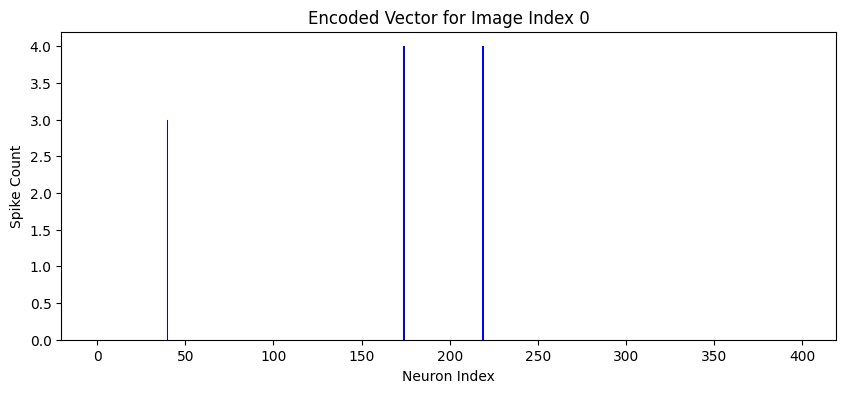

In [27]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from brian2 import *

# Set paths
DATA_PATH = Path('data')
MNIST_PATH = Path('mnist')

# Load pretrained weights
weights = np.load(DATA_PATH / 'XeAe.npy')
theta = np.load(DATA_PATH / 'theta_A.npy')

# Build the network in non-training mode
net = build_network(training=False)

# Load a sample MNIST image
def load_mnist_image(index, training=False):
    tag = 'train' if training else 't10k'
    images = open(MNIST_PATH / ('%s-images-idx3-ubyte' % tag), 'rb')
    images.read(16)  # Skip the header
    images = np.frombuffer(images.read(), dtype=np.uint8).reshape(-1, 784) / 8.0
    return images[index]

# Encode the image
image_index = 0  # Replace with your desired image index
image = load_mnist_image(image_index, training=False)
encoded_vector = show_sample(net, image, INTENSITY)

# Visualize the encoded vector
plt.figure(figsize=(10, 4))
plt.bar(range(len(encoded_vector)), encoded_vector, color='blue')
plt.xlabel('Neuron Index')
plt.ylabel('Spike Count')
plt.title(f'Encoded Vector for Image Index {image_index}')
plt.show()

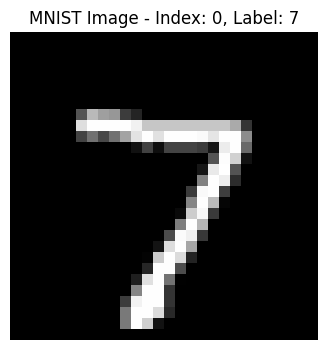

In [28]:
# Load and display an image
image_index = 0  # Replace with desired index
image, label = load_mnist_image_to_show(image_index, training=False)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.title(f'MNIST Image - Index: {image_index}, Label: {label}')
plt.axis('off')
plt.show()

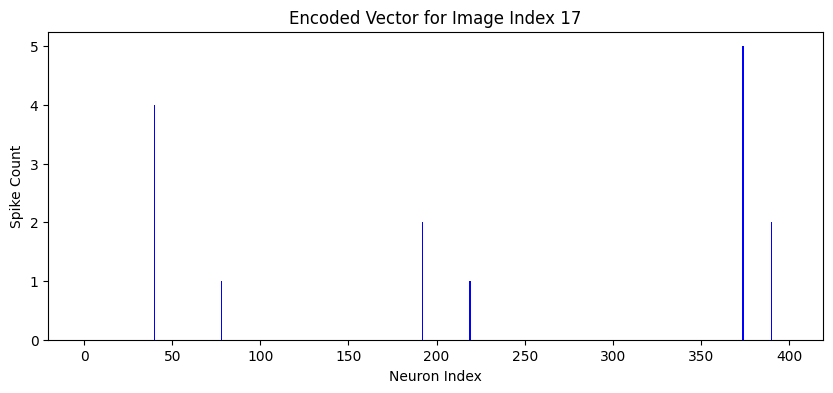

In [29]:
# Encode the image
image_index = 17  # Replace with your desired image index
image = load_mnist_image(image_index, training=False)
encoded_vector = show_sample(net, image, INTENSITY)

# Visualize the encoded vector
plt.figure(figsize=(10, 4))
plt.bar(range(len(encoded_vector)), encoded_vector, color='blue')
plt.xlabel('Neuron Index')
plt.ylabel('Spike Count')
plt.title(f'Encoded Vector for Image Index {image_index}')
plt.show()

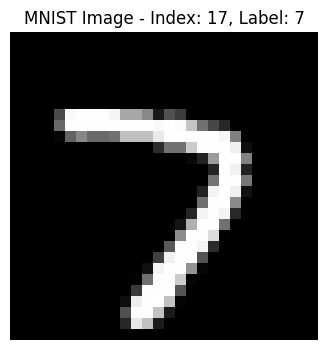

In [30]:
# Load and display an image
image_index = 17  # Replace with desired index
image, label = load_mnist_image_to_show(image_index, training=False)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.title(f'MNIST Image - Index: {image_index}, Label: {label}')
plt.axis('off')
plt.show()

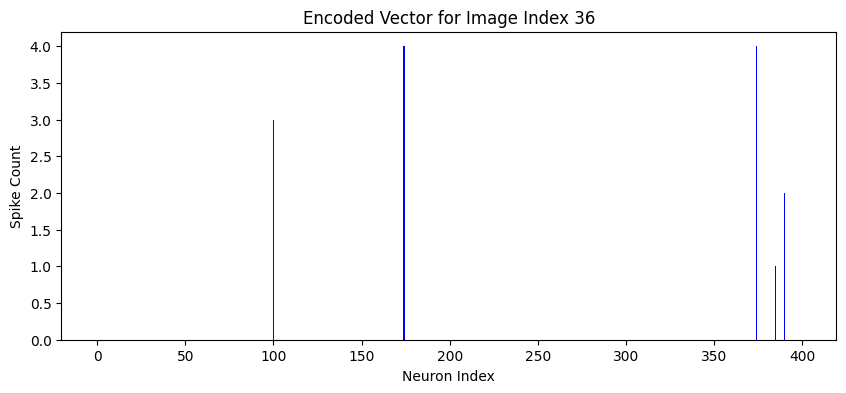

In [31]:
# Encode the image
image_index = 36  # Replace with your desired image index
image = load_mnist_image(image_index, training=False)
encoded_vector = show_sample(net, image, INTENSITY)

# Visualize the encoded vector
plt.figure(figsize=(10, 4))
plt.bar(range(len(encoded_vector)), encoded_vector, color='blue')
plt.xlabel('Neuron Index')
plt.ylabel('Spike Count')
plt.title(f'Encoded Vector for Image Index {image_index}')
plt.show()

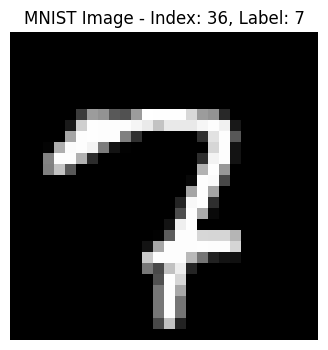

In [ ]:
# Load and display an image
image_index = 36  # Replace with desired index
image, label = load_mnist_image_to_show(image_index, training=False)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.title(f'MNIST Image - Index: {image_index}, Label: {label}')
plt.axis('off')
plt.show()

# 5

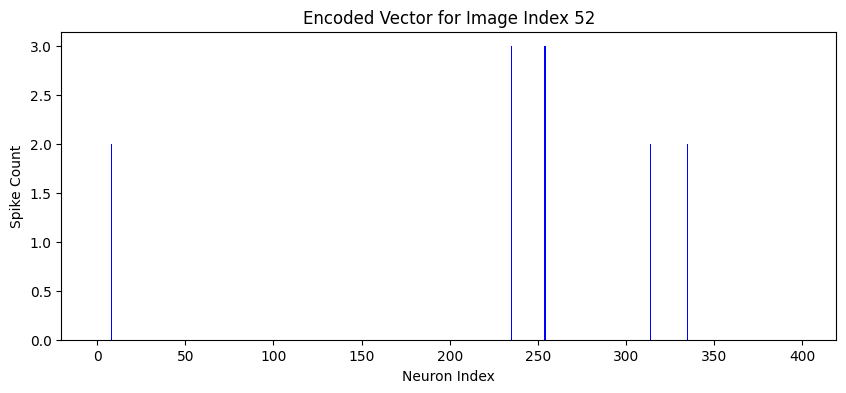

In [32]:
# Encode the image
image_index = 52 # Replace with your desired image index
image = load_mnist_image(image_index, training=False)
encoded_vector = show_sample(net, image, INTENSITY)

# Visualize the encoded vector
plt.figure(figsize=(10, 4))
plt.bar(range(len(encoded_vector)), encoded_vector, color='blue')
plt.xlabel('Neuron Index')
plt.ylabel('Spike Count')
plt.title(f'Encoded Vector for Image Index {image_index}')
plt.show()

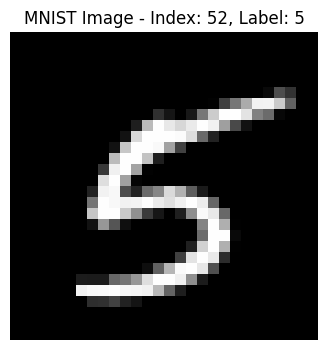

In [ ]:
# Load and display an image
image_index = 52 # Replace with desired index
image, label = load_mnist_image_to_show(image_index, training=False)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.title(f'MNIST Image - Index: {image_index}, Label: {label}')
plt.axis('off')
plt.show()

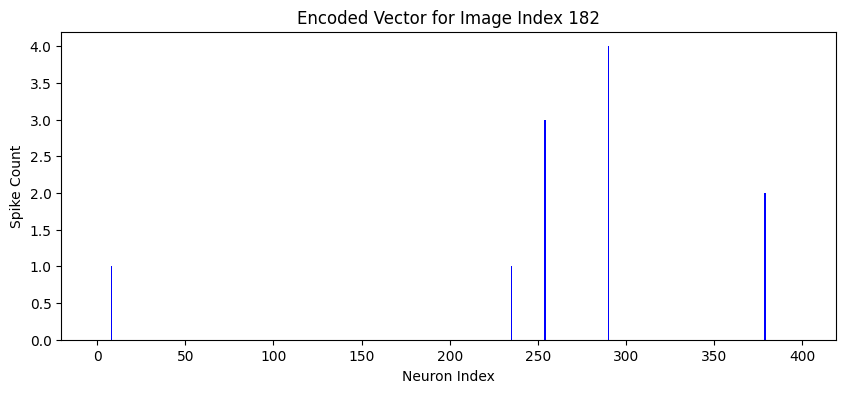

In [61]:
# Encode the image
image_index = 182 # Replace with your desired image index
image = load_mnist_image(image_index, training=False)
encoded_vector = show_sample(net, image, INTENSITY)

# Visualize the encoded vector
plt.figure(figsize=(10, 4))
plt.bar(range(len(encoded_vector)), encoded_vector, color='blue')
plt.xlabel('Neuron Index')
plt.ylabel('Spike Count')
plt.title(f'Encoded Vector for Image Index {image_index}')
plt.show()

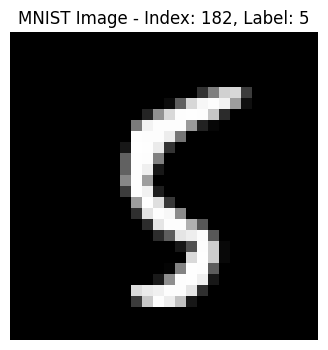

In [60]:
# Load and display an image
image_index = 182 # Replace with desired index
image, label = load_mnist_image_to_show(image_index, training=False)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.title(f'MNIST Image - Index: {image_index}, Label: {label}')
plt.axis('off')
plt.show()

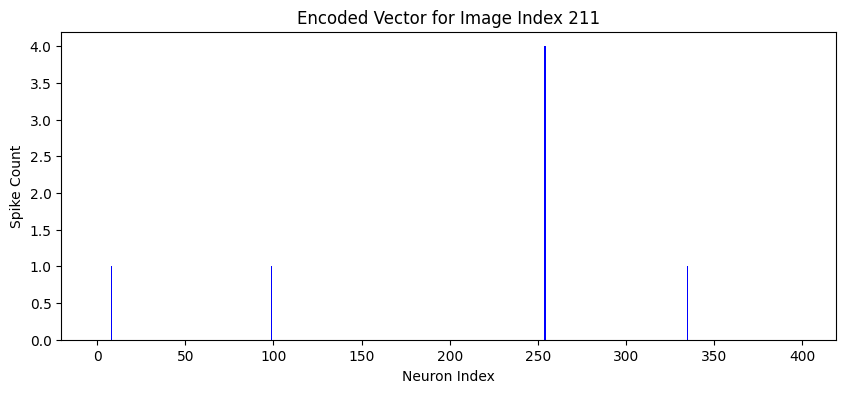

In [78]:
# Encode the image
image_index = 211 # Replace with your desired image index
image = load_mnist_image(image_index, training=False)
encoded_vector = show_sample(net, image, INTENSITY)

# Visualize the encoded vector
plt.figure(figsize=(10, 4))
plt.bar(range(len(encoded_vector)), encoded_vector, color='blue')
plt.xlabel('Neuron Index')
plt.ylabel('Spike Count')
plt.title(f'Encoded Vector for Image Index {image_index}')
plt.show()

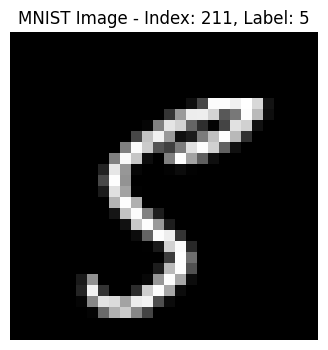

In [76]:
# Load and display an image
image_index = 211 # Replace with desired index
image, label = load_mnist_image_to_show(image_index, training=False)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.title(f'MNIST Image - Index: {image_index}, Label: {label}')
plt.axis('off')
plt.show()

# 4

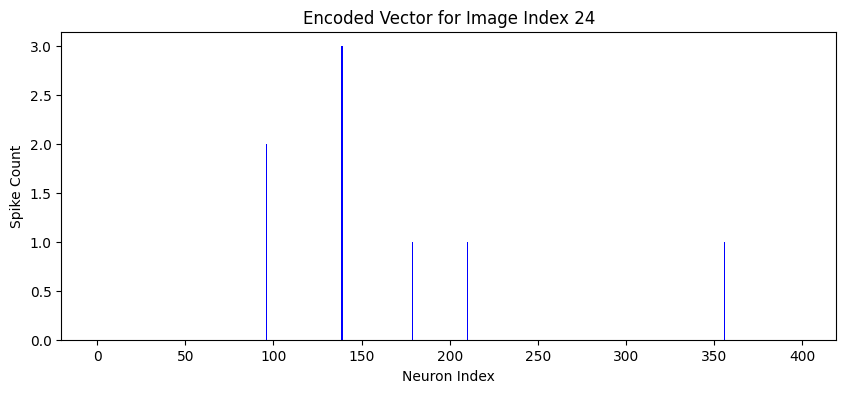

In [ ]:
Ü# Encode the image
image_index = 24 # Replace with your desired image index
image = load_mnist_image(image_index, training=False)
encoded_vector = show_sample(net, image, INTENSITY)

# Visualize the encoded vector
plt.figure(figsize=(10, 4))
plt.bar(range(len(encoded_vector)), encoded_vector, color='blue')
plt.xlabel('Neuron Index')
plt.ylabel('Spike Count')
plt.title(f'Encoded Vector for Image Index {image_index}')
plt.show()

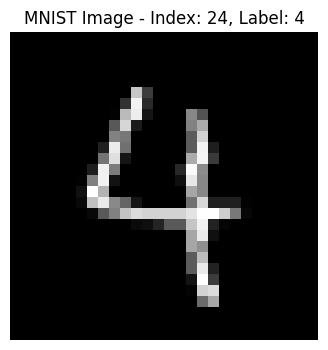

In [ ]:
# Load and display an image
image_index = 24# Replace with desired index
image, label = load_mnist_image_to_show(image_index, training=False)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.title(f'MNIST Image - Index: {image_index}, Label: {label}')
plt.axis('off')
plt.show()

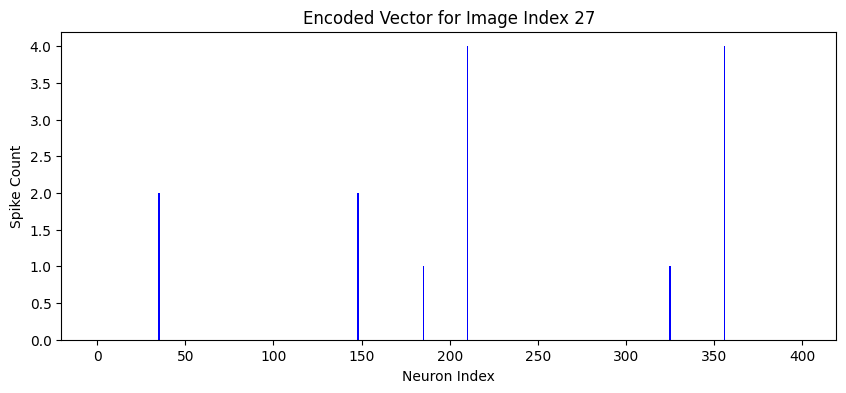

In [ ]:
# Encode the image
image_index = 27 # Replace with your desired image index
image = load_mnist_image(image_index, training=False)
encoded_vector = show_sample(net, image, INTENSITY)

# Visualize the encoded vector
plt.figure(figsize=(10, 4))
plt.bar(range(len(encoded_vector)), encoded_vector, color='blue')
plt.xlabel('Neuron Index')
plt.ylabel('Spike Count')
plt.title(f'Encoded Vector for Image Index {image_index}')
plt.show()

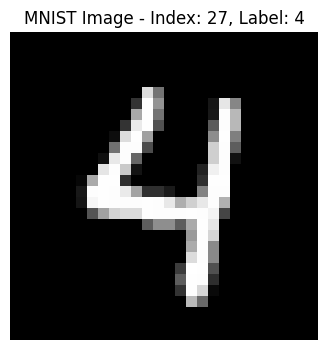

In [ ]:
# Load and display an image
image_index = 27# Replace with desired index
image, label = load_mnist_image_to_show(image_index, training=False)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.title(f'MNIST Image - Index: {image_index}, Label: {label}')
plt.axis('off')
plt.show()

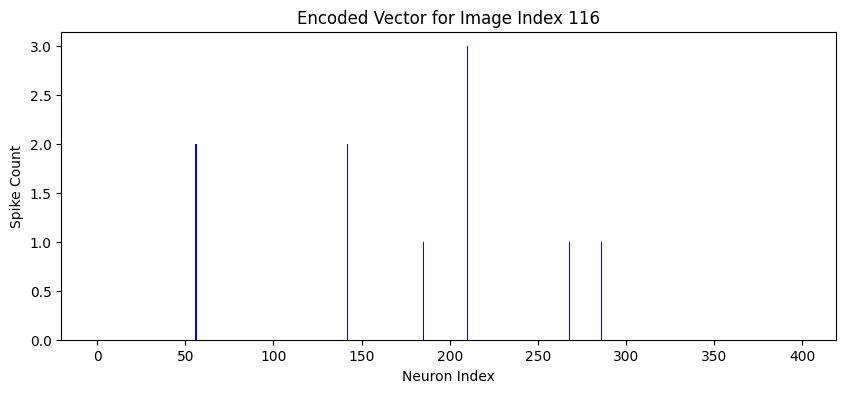

In [41]:
# Encode the image
image_index = 116 # Replace with your desired image index
image = load_mnist_image(image_index, training=False)
encoded_vector = show_sample(net, image, INTENSITY)

# Visualize the encoded vector
plt.figure(figsize=(10, 4))
plt.bar(range(len(encoded_vector)), encoded_vector, color='blue')
plt.xlabel('Neuron Index')
plt.ylabel('Spike Count')
plt.title(f'Encoded Vector for Image Index {image_index}')
plt.show()

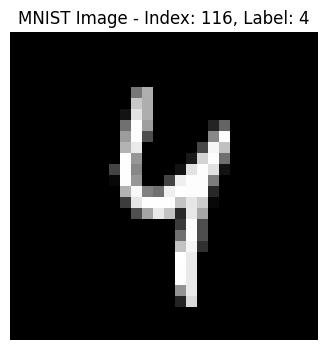

In [42]:
# Load and display an image
image_index = 116 # Replace with desired index
image, label = load_mnist_image_to_show(image_index, training=False)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.title(f'MNIST Image - Index: {image_index}, Label: {label}')
plt.axis('off')
plt.show()

In [ ]:
encoded_vector

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,